In [1]:
import numpy as np
from scipy.stats import linregress
from utils import load_data, load_param
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from data_analysis import fit_linear_background_iterative
from glob import glob
import os
from science import laser_current_to_freq_MHz, get_852_RabiFreq_MHz, laser_current_to_freq_MHz_2

In [2]:
def reduced_data(filename, zero_point=72.835):
    x, y = load_data(filename)
    y = y-(-0.013)
    a, b, _, _ = fit_linear_background_iterative(x,y, n_iter=3)
    yf = y/(a* x + b)
    xf = laser_current_to_freq_MHz(x, zero_point)
    original_data = [x[25:100], y[25:100]]

    return xf[25:100], yf[25:100], np.average(a*x + b -(-0.013)), original_data


In [26]:
#p852_mW=3 data
parent_3 = "04122026/04122026-130418-spec/"
dataf_ls_3 = np.sort(glob(parent_3+"data_*.csv"))
#p852_mW=7 data
parent_7 =  "04132026/data-p852=7.3mW/"
dataf_ls_7 = np.sort(glob(parent_7+"data_*.csv"))
#852_mW=11.1 data
parent_11 = "04112026/04112026-154320-spec/"
dataf_ls_11 = np.sort(glob(parent_11+"data_*.csv"))
#p852_mW=27.7 data
parent_28 = "04112026/04112026-233630-spec/"
dataf_ls_28 = np.sort(glob(parent_28+"data_*.csv"))
dataf_ls = np.sort(glob(parent+"data_*.csv"))
paramf_ls = np.sort(glob(parent+"params_*.json"))
max_bg = 0.8126273684210527


NameError: name 'parent' is not defined

60
0.8126273684210527


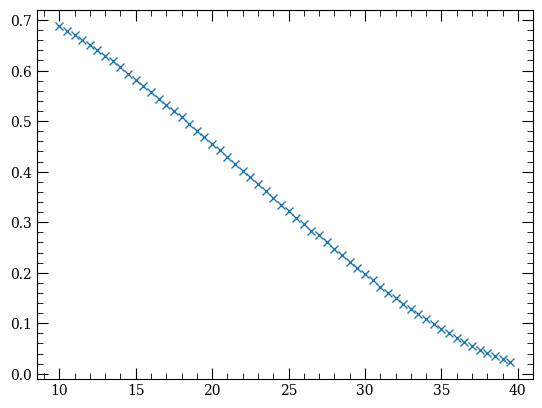

In [155]:
#p852_mW=3 data
#parent = "04122026/04122026-130418-spec/"
#p852_mw= 7.327
parent = "04132026/data-p852=7.3mW/"

#852_mW=11.1 data
#parent = "04112026/04112026-154320-spec/"




dataf_ls = np.sort(glob(parent+"data_*.csv"))[20:80]
paramf_ls = np.sort(glob(parent+"params_*.json"))[20:80]
print(len(dataf_ls))

l2_pos_deg = [load_param(paramf)["l2_position_deg"] for paramf in paramf_ls]
bg = [np.average(load_data(dataf)[1][-20:-1]) for dataf in dataf_ls]
max_bg = 0.8126273684210527
print(max_bg)
plt.plot(l2_pos_deg, bg, "x")


In [156]:
xf,yf,_, original_data = reduced_data(dataf_ls[80])
x, y = original_data
#print(x)
a = 0
ymin=1.02
ymax=+0.9
#6->5
plt.vlines(a, ymin, ymax, color="blue")
#5->5
plt.vlines(a+127.2, ymin, ymax, color="red")
#4->5
plt.vlines(a+127.2+106.0, ymin, ymax, color="blue")
#5->4
plt.vlines(a+127.2+251.1, ymin, ymax, color="blue")
#4->4
plt.vlines(a+127.2+106.0+251.1, ymin, ymax, color="blue")
#3->4
plt.vlines(a+127.2+106.0+251.1+84.8, ymin, ymax, color="blue")
#4->3
plt.vlines(a+ 127.2 +106.0 + 251.1+ 201.3, ymin, ymax, color="blue")
#3->3
plt.vlines(a+ 127.2 +106.0 + 251.1+ 201.3+84.8, ymin, ymax, color="blue")
#3->2
plt.vlines(a+ 127.2 +106.0 + 251.1+ 201.3+84.8+ 151.2, ymin, ymax, color="blue")
plt.plot(xf,yf, ".-")

IndexError: index 80 is out of bounds for axis 0 with size 60

In [157]:
transitions = [
    (0,                                        "blue",  "6→5"),
    (127.4,                                    "red",   "5→5"),
    (127.4 + 106.2,                            "blue",  "4→5"),
    (127.4 + 251.1,                            "blue",  "5→4"),
    (127.4 + 106.2 + 251.1,                    "blue",  "4→4"),
    (127.4 + 106.2 + 251.1 + 85,              "blue",  "3→4"),
    (127.4 + 106.2 + 251.1 + 201.3,           "blue",  "4→3"),
    (127.4 + 106.2 + 251.1 + 201.3 + 85,      "blue",  "3→3"),
    (127.4 + 106.2 + 251.1 + 201.3 + 85 + 151.2, "blue", "3→2"),
]

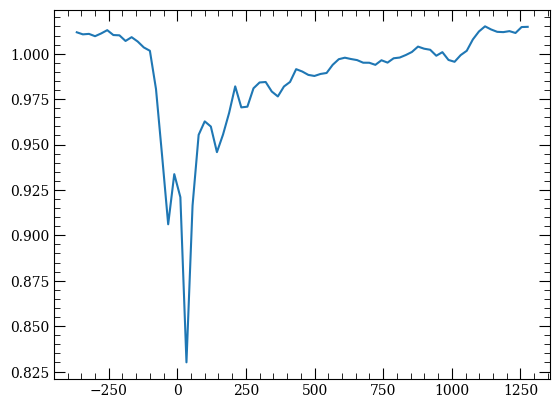

In [158]:
plt.plot(xf, yf)

In [ ]:
(56,59) 

Text(0.5, 1.0, '$\\Omega_{3491}$= 2$\\pi \\times 53.7$ MHz')

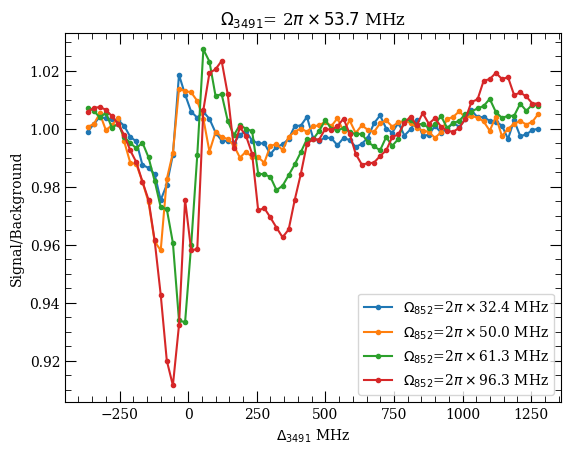

In [34]:
for file in dataf_ls_3:
    x, y, bg, _ = reduced_data(file)
    if 0.70 < bg < 0.706:
        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent_3+f"params_{idx}.json")

        p852 = params["p852_mW"]
        p852 = get_852_RabiFreq_MHz((params["p852_mW"]))
        plt.plot(x, y,".-", label=fr"$\Omega_{{852}}$=2$\pi\times${p852:.1f} MHz")
        break


for file in dataf_ls_7:
    x, y, bg, _ = reduced_data(file)
    if 0.70 < bg < 0.705:
        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent_7+f"params_{idx}.json")

        p852 = params["p852_mW"]
        p852 = get_852_RabiFreq_MHz((params["p852_mW"]))
        plt.plot(x, y,".-", label=fr"$\Omega_{{852}}$=2$\pi\times${p852:.1f} MHz")
        break
for file in dataf_ls_11:
    x, y, bg, _ = reduced_data(file)
    if 0.70 < bg < 0.705:
        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent_11+f"params_{idx}.json")

        p852 = params["p852_mW"]
        p852 = get_852_RabiFreq_MHz((params["p852_mW"]))
        plt.plot(x, y,".-", label=fr"$\Omega_{{852}}$=2$\pi\times${p852:.1f} MHz")
        break

for file in dataf_ls_28:
    x, y, bg, _ = reduced_data(file)
    if 0.70 < bg < 0.706:
        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent_28+f"params_{idx}.json")

        p852 = get_852_RabiFreq_MHz((params["p852_mW"]))
        plt.plot(x, y,".-", label=fr"$\Omega_{{852}}$=2$\pi\times${p852:.1f} MHz")
        break

Omega_3491 = 0.703/0.812 * 62

plt.legend()
plt.ylabel("Signal/Background")
plt.xlabel(r"$\Delta_{3491}$ MHz")
plt.title(fr"$\Omega_{{3491}}$= 2$\pi \times {Omega_3491:.1f}$ MHz")

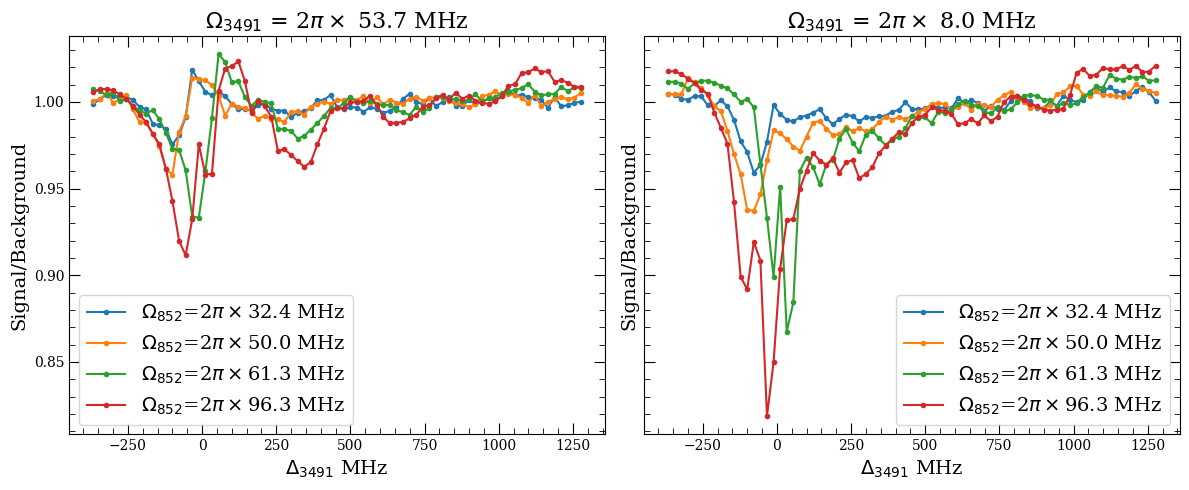

In [41]:
import os
import matplotlib.pyplot as plt


datasets = [
    (dataf_ls_3,  parent_3),
    (dataf_ls_7,  parent_7),
    (dataf_ls_11, parent_11),
    (dataf_ls_28, parent_28),
]

def plot_for_bg_range(ax, bg_low, bg_high):
    for dataf_ls, parent in datasets:
        for file in dataf_ls:
            x, y, bg, _ = reduced_data(file)
            if bg_low < bg < bg_high:
                idx = os.path.splitext(file)[0].split("_")[-1]
                params = load_param(parent + f"params_{idx}.json")
                p852 = get_852_RabiFreq_MHz(params["p852_mW"])
                ax.plot(x, y, ".-", label=fr"$\Omega_{{852}}$=2$\pi\times${p852:.1f} MHz")
                break

    ax.legend(fontsize=14)
    ax.set_ylabel("Signal/Background", fontsize=14)
    ax.set_xlabel(r"$\Delta_{3491}$ MHz", fontsize=14)
    Omega_3491 = (bg_low+bg_high)/2 /0.812 * 62
    ax.set_title(fr"$\Omega_{{3491}}$ = 2$\pi \times$ {Omega_3491:.1f} MHz", fontsize=16)

# choose the two bg windows
bg_range1 = (0.70, 0.706)
bg_range2 = (0.1, 0.11)   # change this

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_for_bg_range(ax1, *bg_range1)
plot_for_bg_range(ax2, *bg_range2)



plt.tight_layout()
plt.show()

Text(0.5, 1.0, '$\\Omega_{852}$= 2$\\pi \\times 50.0$ MHz')

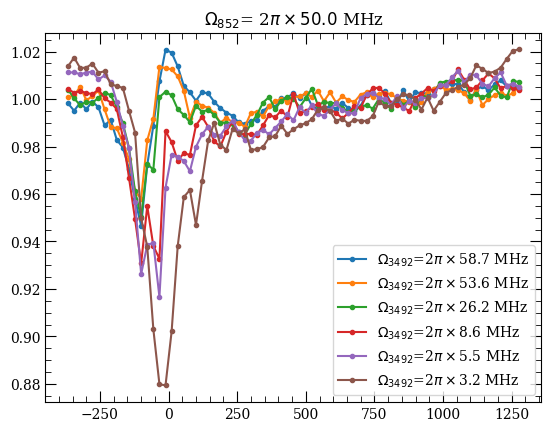

In [55]:
for i in range(len(dataf_ls_7)):
    x, y, bg, _ = reduced_data(dataf_ls_7[i])
    if i in [0, 20, 50, 70,75,80]:
        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent_7+f"params_{idx}.json")

        p852 = params["p852_mW"]
        Omega_852 = get_852_RabiFreq_MHz((params["p852_mW"]))
        Omega_3491 = bg /0.812 * 62

        plt.plot(x, y,".-", label=fr"$\Omega_{{3492}}$=2$\pi\times${Omega_3491:.1f} MHz")
plt.legend()
plt.title("")
plt.title(fr"$\Omega_{{852}}$= 2$\pi \times {Omega_852:.1f}$ MHz")

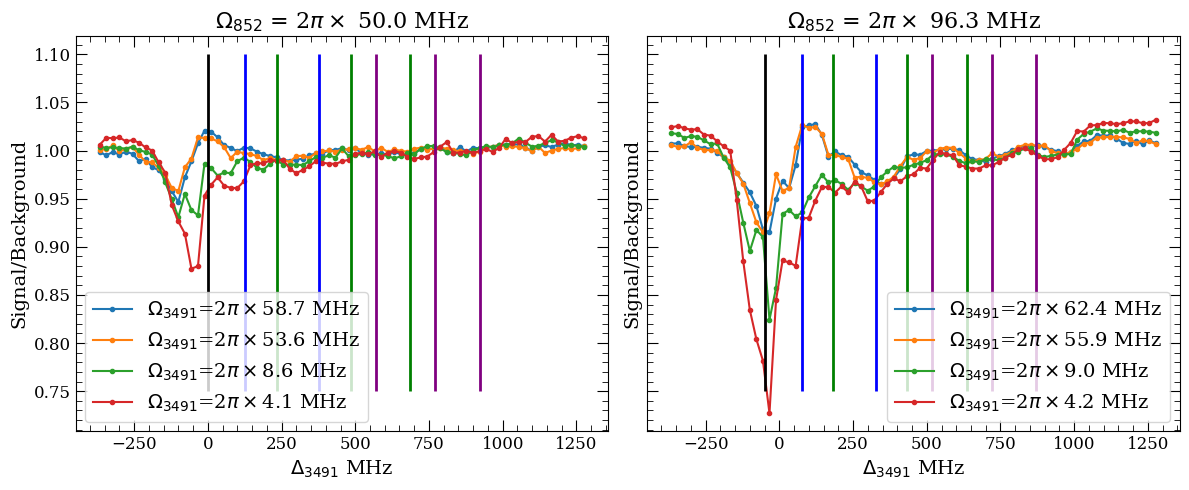

In [71]:
import os
import matplotlib.pyplot as plt

def plot_parent(ax, dataf_ls, parent, idx_list):
    Omega_852_for_title = None

    for i in range(len(dataf_ls)):
        if i not in idx_list:
            continue

        file = dataf_ls[i]
        x, y, bg, _ = reduced_data(file)

        idx = os.path.splitext(file)[0].split("_")[-1]
        params = load_param(parent + f"params_{idx}.json")

        Omega_852 = get_852_RabiFreq_MHz(params["p852_mW"])
        Omega_3491 = bg / 0.812 * 62

        if Omega_852_for_title is None:
            Omega_852_for_title = Omega_852

        ax.plot(x, y, ".-", label=fr"$\Omega_{{3491}}$=2$\pi\times${Omega_3491:.1f} MHz")

    ax.legend(fontsize=14)
    ax.set_xlabel(r"$\Delta_{3491}$ MHz", fontsize=14)
    ax.set_ylabel("Signal/Background", fontsize=14)
    ax.set_title(fr"$\Omega_{{852}}$ = 2$\pi \times$ {Omega_852_for_title:.1f} MHz", fontsize=16)
    ax.tick_params(labelsize=12)


idx_list = [0, 20, 70, 78]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_parent(axes[0], dataf_ls_7, parent_7, idx_list)
plot_parent(axes[1], dataf_ls_28, parent_28, idx_list)   # change to the other parent you want
plot_transition_lines(axes[0], 0, 0.75, 1.1)
plot_transition_lines(axes[1], -50, 0.75, 1.1)
plt.tight_layout()
plt.show()

In [65]:
def plot_transition_lines(ax, a, ymin, ymax):
    color_map = {
        6: "black",
        5: "blue",
        4: "green",
        3: "purple",
    }

    transitions = [
        ("6->5", 0, 6),
        ("5->5", 127.2, 5),
        ("4->5", 127.2 + 106.0, 4),
        ("5->4", 127.2 + 251.1, 5),
        ("4->4", 127.2 + 106.0 + 251.1, 4),
        ("3->4", 127.2 + 106.0 + 251.1 + 84.8, 3),
        ("4->3", 127.2 + 106.0 + 251.1 + 201.3, 4),
        ("3->3", 127.2 + 106.0 + 251.1 + 201.3 + 84.8, 3),
        ("3->2", 127.2 + 106.0 + 251.1 + 201.3 + 84.8 + 151.2, 3),
    ]

    line_info = []

    for label, offset, start_state in transitions:
        x_pos = a + offset
        color = color_map[start_state]

        line = ax.vlines(x_pos, ymin, ymax, color=color, linewidth=2)

        line_info.append({
            "label": label,
            "x": x_pos,
            "start_state": start_state,
            "line": line
        })

    return line_info